In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
#https://www.kaggle.com/datasets/sonalshinde123/student-placement-dataset
from pandas import read_csv
df=read_csv("placement_predict_50k Dataset.csv")

In [ ]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus', 'IsAnomaly', 'Salary Package']
Categorical Features: ['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']


In [ ]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [ ]:
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                    StudentID  SGPA_Sem1  SGPA_Sem2  SGPA_Sem3  SGPA_Sem4  \
StudentID            1.000000  -0.004221  -0.004321  -0.003670  -0.002203   
SGPA_Sem1           -0.004221   1.000000   0.963951   0.963790   0.963600   
SGPA_Sem2           -0.004321   0.963951   1.000000   0.964915   0.964800   
SGPA_Sem3           -0.003670   0.963790   0.964915   1.000000   0.965753   
SGPA_Sem4           -0.002203   0.963600   0.964800   0.965753   1.000000   
SGPA_Sem5           -0.002920   0.963188   0.964754   0.965477   0.966570   
SGPA_Sem6           -0.002474   0.962474   0.964251   0.965877   0.966524   
SGPA_Sem7           -0.002470   0.961925   0.963900   0.965480   0.966349   
SGPA_Sem8           -0.003057   0.960640   0.962899   0.964778   0.966118   
CGPA                -0.002534   0.911463   0.912570   0.913174   0.913727   
AttendancePercent    0.000299   0.496737   0.506104   0.513868   0.521876   
Internships          0.002501   0.446370   0.455

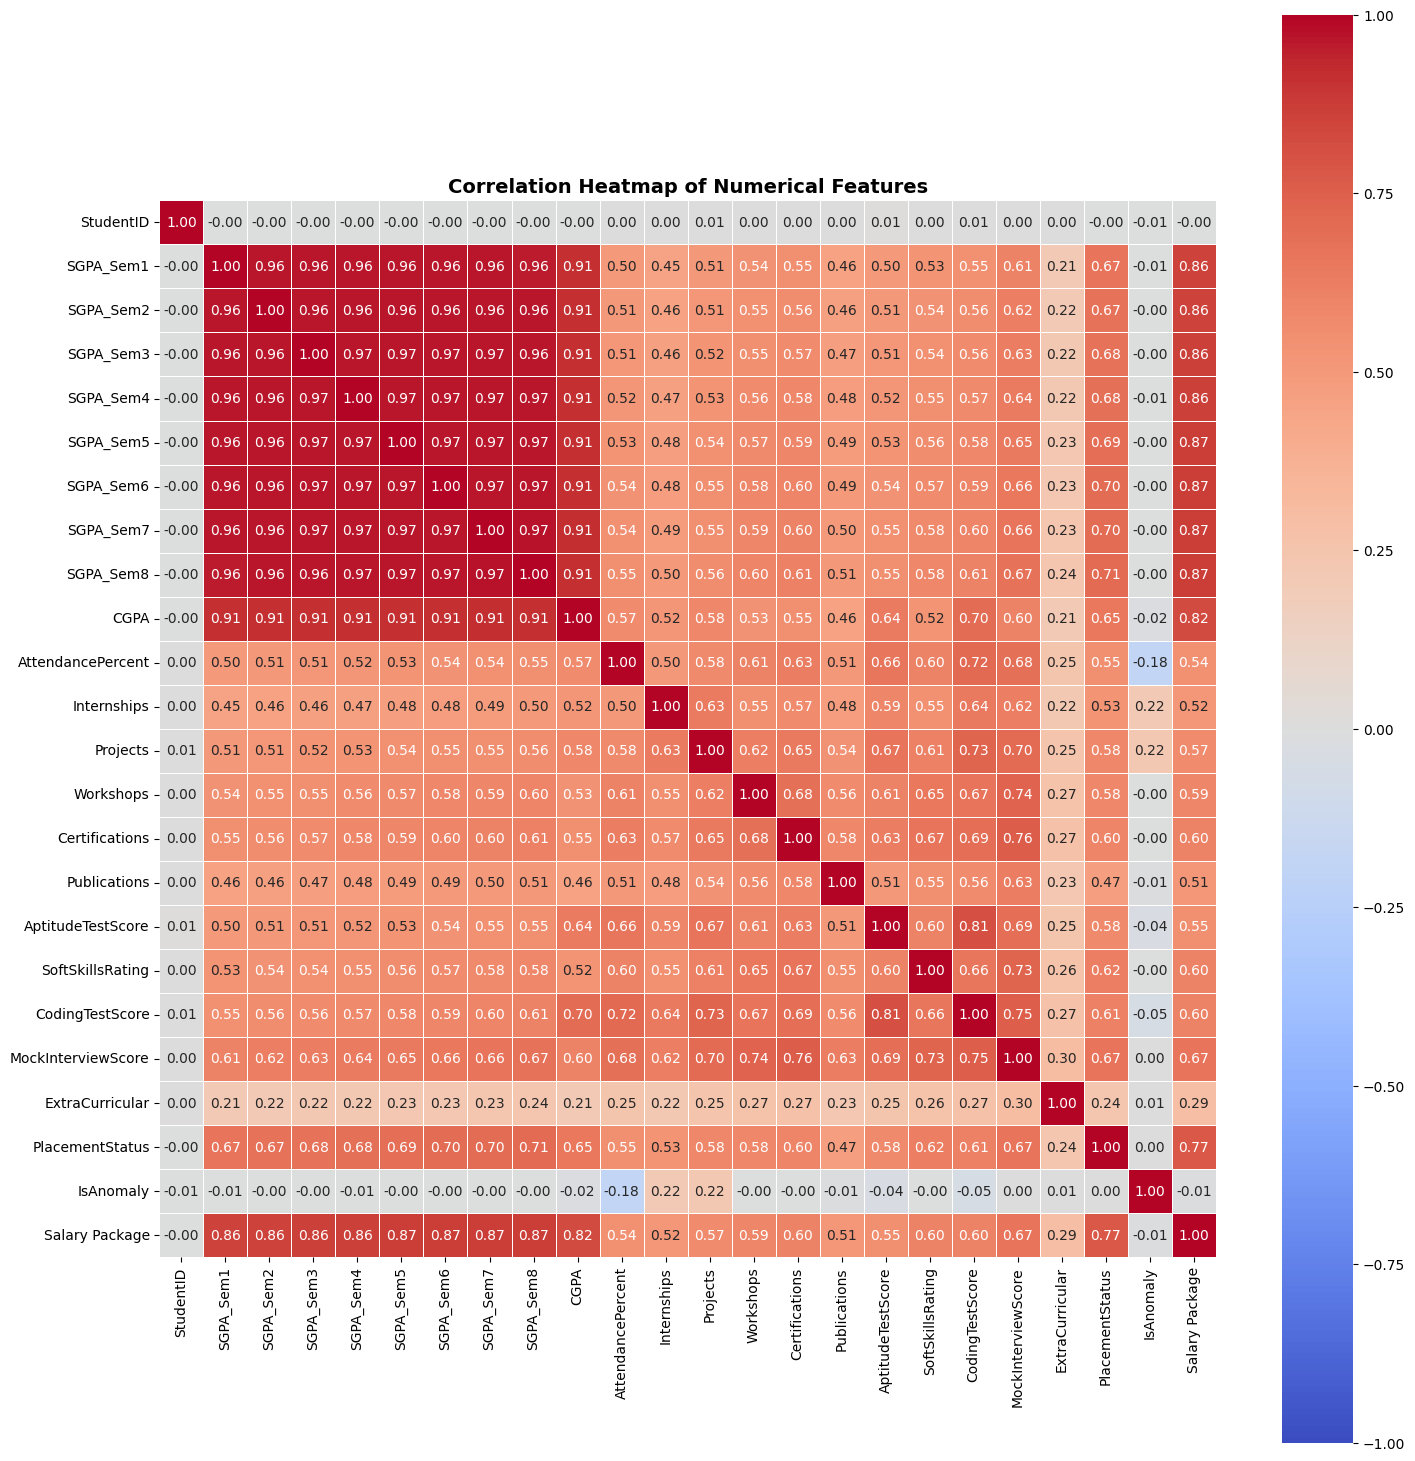

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [ ]:
import os
output_dir = "./reports"

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: ./reports/correlation_heatmap.png


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

target_col = "PlacementStatus"
output_dir = "./reports" # Explicitly define output_dir within this cell
os.makedirs(output_dir, exist_ok=True) # Ensure directory exists

if target_col in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)
        plt.tight_layout()


        # Save the boxplot
        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"

        # Create complete file path
        boxplot_path = os.path.join(output_dir, boxplot_filename)

        # Save the figure
        plt.savefig(boxplot_path,    dpi=300,    bbox_inches="tight")

        # Close the figure
        plt.close()

        # Display confirmation message
        print(f"Exported boxplot to: {boxplot_path}")

else:
    print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

    print("\nAll EDA tasks completed successfully!")

Exported boxplot to: ./reports/boxplot_StudentID_vs_PlacementStatus.png
Exported boxplot to: ./reports/boxplot_SGPA_Sem1_vs_PlacementStatus.png
Exported boxplot to: ./reports/boxplot_SGPA_Sem2_vs_PlacementStatus.png
Exported boxplot to: ./reports/boxplot_SGPA_Sem3_vs_PlacementStatus.png
Exported boxplot to: ./reports/boxplot_SGPA_Sem4_vs_PlacementStatus.png
Exported boxplot to: ./reports/boxplot_SGPA_Sem5_vs_PlacementStatus.png
Exported boxplot to: ./reports/boxplot_SGPA_Sem6_vs_PlacementStatus.png
Exported boxplot to: ./reports/boxplot_SGPA_Sem7_vs_PlacementStatus.png
Exported boxplot to: ./reports/boxplot_SGPA_Sem8_vs_PlacementStatus.png
Exported boxplot to: ./reports/boxplot_CGPA_vs_PlacementStatus.png
Exported boxplot to: ./reports/boxplot_AttendancePercent_vs_PlacementStatus.png
Exported boxplot to: ./reports/boxplot_Internships_vs_PlacementStatus.png
Exported boxplot to: ./reports/boxplot_Projects_vs_PlacementStatus.png
Exported boxplot to: ./reports/boxplot_Workshops_vs_Placemen

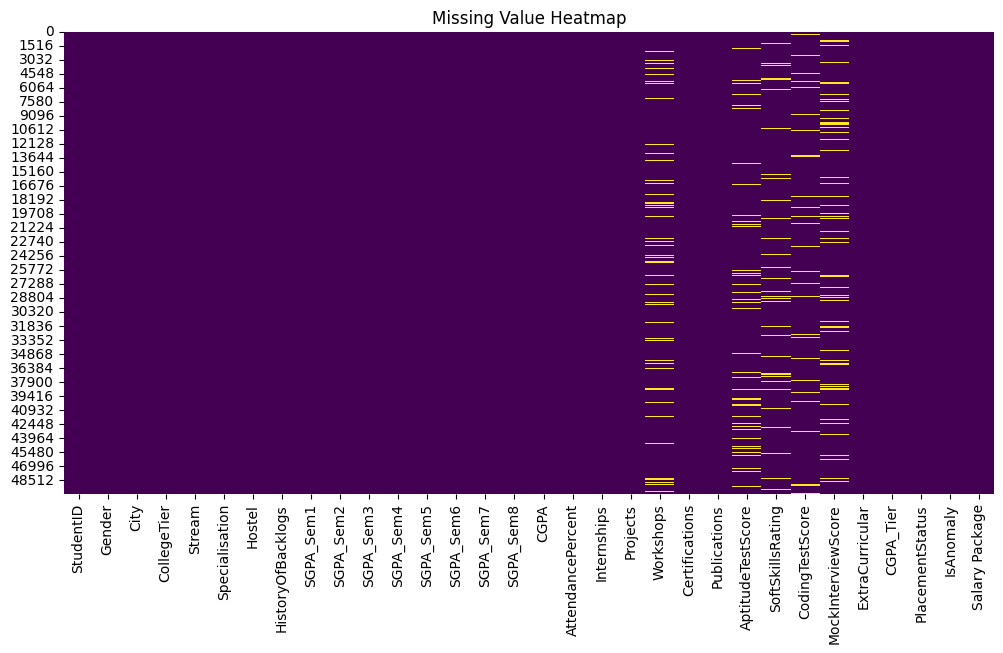

In [ ]:
import matplotlib.pyplot as plt
fig1=plt.figure(figsize=(12,6))

sns.heatmap(
         df.isnull(),
        cbar=False,
         cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()